In [1]:
!pip install torch torchvision matplotlib seaborn scikit-learn \
             opencv-python kagglehub --quiet
print('Packages installed!')

You should consider upgrading via the '/Users/akhileshkumar/.pyenv/versions/3.10.5/bin/python3.10 -m pip install --upgrade pip' command.
Packages installed!


In [ ]:
DATA_DIR = "brain-tumour-data/brain_tumor_dataset"

if DATA_DIR is None:
    raise FileNotFoundError('Could not find yes/ and no/ folders. Check cache_path above.')

yes_count = len(os.listdir(os.path.join(DATA_DIR, 'yes')))
no_count  = len(os.listdir(os.path.join(DATA_DIR, 'no')))
print(f'DATA_DIR  : {DATA_DIR}')
print(f'Tumor (yes): {yes_count} images')
print(f'Normal (no): {no_count} images')
print(f'Total      : {yes_count + no_count} images')

DATA_DIR  : brain-tumour-data/brain_tumor_dataset
Tumor (yes): 155 images
Normal (no): 98 images
Total      : 253 images


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import numpy as np
import cv2
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [6]:
IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

full_dataset = torchvision.datasets.ImageFolder(root=DATA_DIR, transform=train_tf)
CLASS_NAMES  = full_dataset.classes   # ['no', 'yes']
print(f'Classes : {CLASS_NAMES}  (0={CLASS_NAMES[0]}, 1={CLASS_NAMES[1]})')

n_train = int(0.8 * len(full_dataset))
n_val   = len(full_dataset) - n_train
train_set, val_set = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42))

val_set.dataset = torchvision.datasets.ImageFolder(root=DATA_DIR, transform=val_tf)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=16, shuffle=False)

print(f'Train : {n_train}  |  Val : {n_val}')

Classes : ['no', 'yes']  (0=no, 1=yes)
Train : 202  |  Val : 51


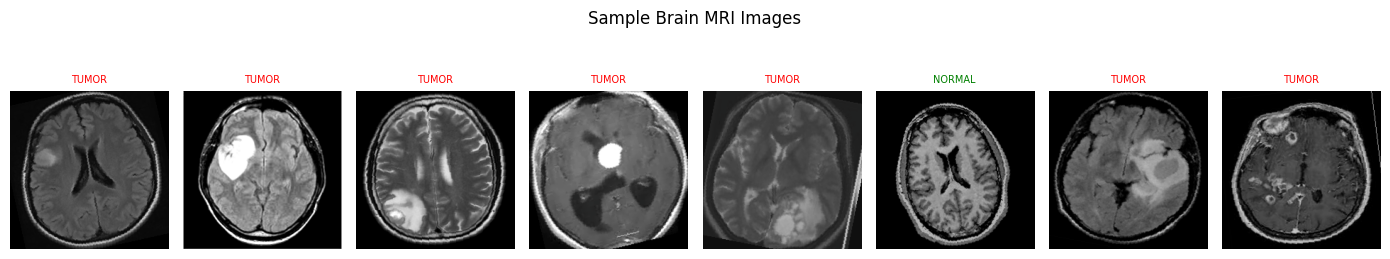

In [7]:
def denorm(tensor):
    """Reverse ImageNet normalization for display."""
    m = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    s = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor * s + m).clamp(0, 1).permute(1,2,0).numpy()

imgs, lbls = next(iter(train_loader))
plt.figure(figsize=(14, 3))
for i in range(min(8, len(imgs))):
    plt.subplot(1, 8, i+1)
    plt.imshow(denorm(imgs[i]))
    name  = CLASS_NAMES[lbls[i].item()]
    color = 'red' if name == 'yes' else 'green'
    plt.title('TUMOR' if name=='yes' else 'NORMAL', fontsize=7, color=color)
    plt.axis('off')
plt.suptitle('Sample Brain MRI Images', fontsize=12)
plt.tight_layout(); plt.show()

In [8]:
class BrainTumorNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        for name, param in self.backbone.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False

        self.backbone.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.backbone(x)


model = BrainTumorNet().to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params : {trainable:,} / {total:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/akhileshkumar/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [01:50<00:00, 424kB/s] 

Trainable params : 8,459,650 / 11,242,434


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5)

NUM_EPOCHS   = 15
best_val_acc = 0
history      = {'train_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    run_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward(); optimizer.step()
        run_loss += loss.item()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            _, pred  = model(imgs.to(device)).max(1)
            correct += pred.eq(lbls.to(device)).sum().item()
            total   += lbls.size(0)

    avg_loss = run_loss / len(train_loader)
    val_acc  = 100. * correct / total
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(val_acc)
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_brain_model.pth')
        tag = '  ← best'
    else:
        tag = ''

    print(f'Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  '
          f'Loss: {avg_loss:.4f}  Val Acc: {val_acc:.1f}%{tag}')

print(f'\nBest Val Accuracy: {best_val_acc:.1f}%')

Epoch [ 1/15]  Loss: 0.6104  Val Acc: 76.5%  ← best
Epoch [ 2/15]  Loss: 0.3897  Val Acc: 86.3%  ← best
Epoch [ 3/15]  Loss: 0.2553  Val Acc: 90.2%  ← best
Epoch [ 4/15]  Loss: 0.1791  Val Acc: 98.0%  ← best
Epoch [ 5/15]  Loss: 0.1187  Val Acc: 94.1%
Epoch [ 6/15]  Loss: 0.0794  Val Acc: 88.2%
Epoch [ 7/15]  Loss: 0.0897  Val Acc: 94.1%
Epoch [ 8/15]  Loss: 0.1046  Val Acc: 94.1%
Epoch [ 9/15]  Loss: 0.0412  Val Acc: 94.1%
Epoch [10/15]  Loss: 0.0715  Val Acc: 96.1%
Epoch [11/15]  Loss: 0.0191  Val Acc: 94.1%
Epoch [12/15]  Loss: 0.0842  Val Acc: 94.1%
Epoch [13/15]  Loss: 0.0593  Val Acc: 94.1%
Epoch [14/15]  Loss: 0.0653  Val Acc: 92.2%
Epoch [15/15]  Loss: 0.0432  Val Acc: 94.1%

Best Val Accuracy: 98.0%


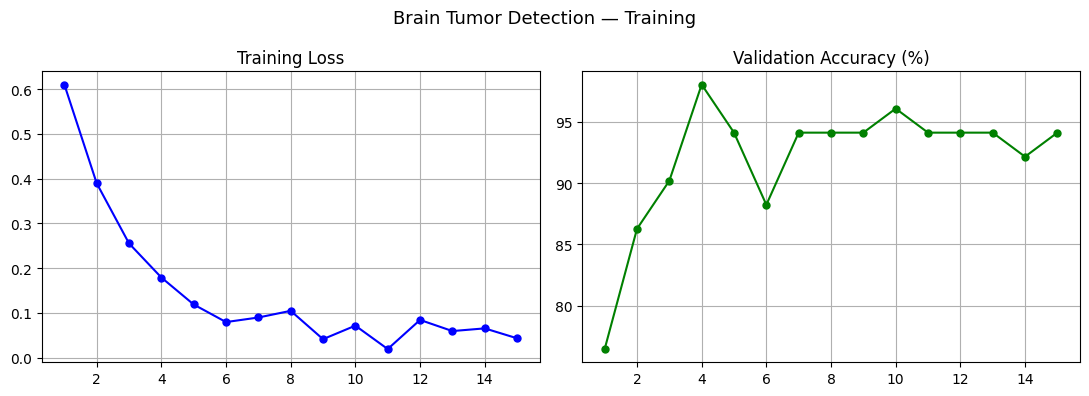

In [10]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(epochs, history['train_loss'], 'b-o', markersize=5)
ax1.set_title('Training Loss'); ax1.grid(True)
ax2.plot(epochs, history['val_acc'], 'g-o', markersize=5)
ax2.set_title('Validation Accuracy (%)'); ax2.grid(True)
plt.suptitle('Brain Tumor Detection — Training', fontsize=13)
plt.tight_layout(); plt.show()

conv1 filters shape: torch.Size([64, 3, 7, 7])


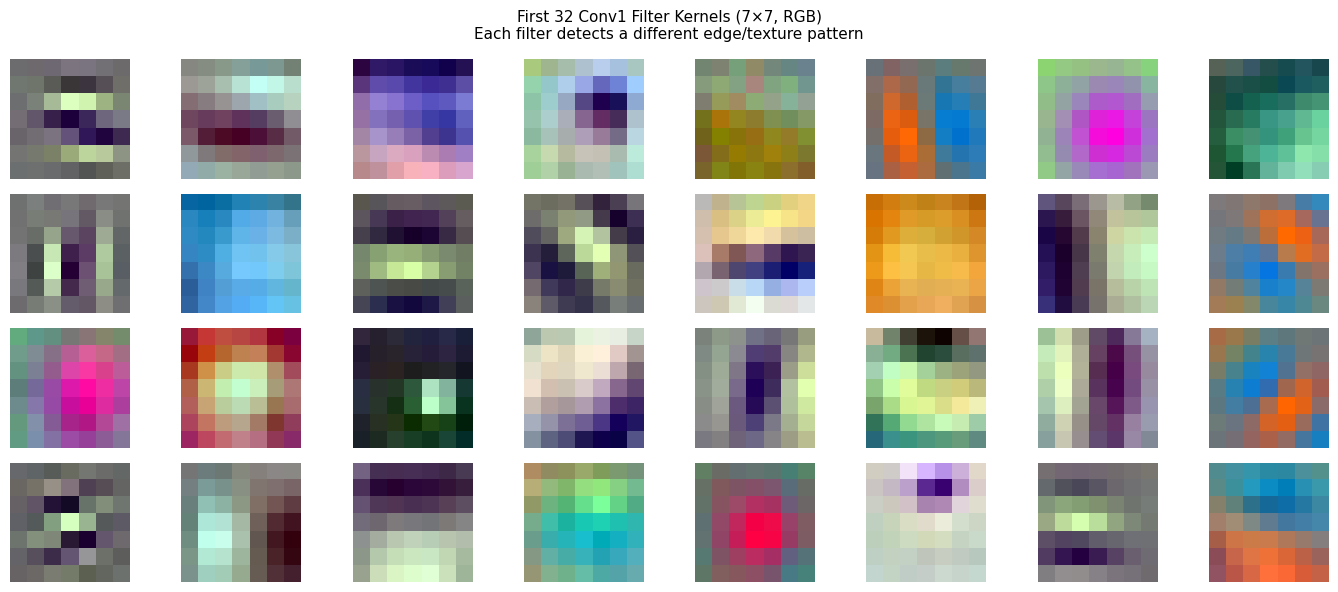

In [11]:
model.load_state_dict(torch.load('best_brain_model.pth', map_location=device))
model.eval()

first_conv = model.backbone.conv1  
filters    = first_conv.weight.data.cpu()
print(f'conv1 filters shape: {filters.shape}')  

def norm01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

n_show = 32
plt.figure(figsize=(14, 6))
for i in range(n_show):
    plt.subplot(4, 8, i+1)
    filt = norm01(filters[i]).permute(1, 2, 0).numpy()
    plt.imshow(filt)
    plt.axis('off')
plt.suptitle(f'First {n_show} Conv1 Filter Kernels (7×7, RGB)\nEach filter detects a different edge/texture pattern',
             fontsize=11)
plt.tight_layout(); plt.show()

Layer4 output shape: torch.Size([512, 7, 7])


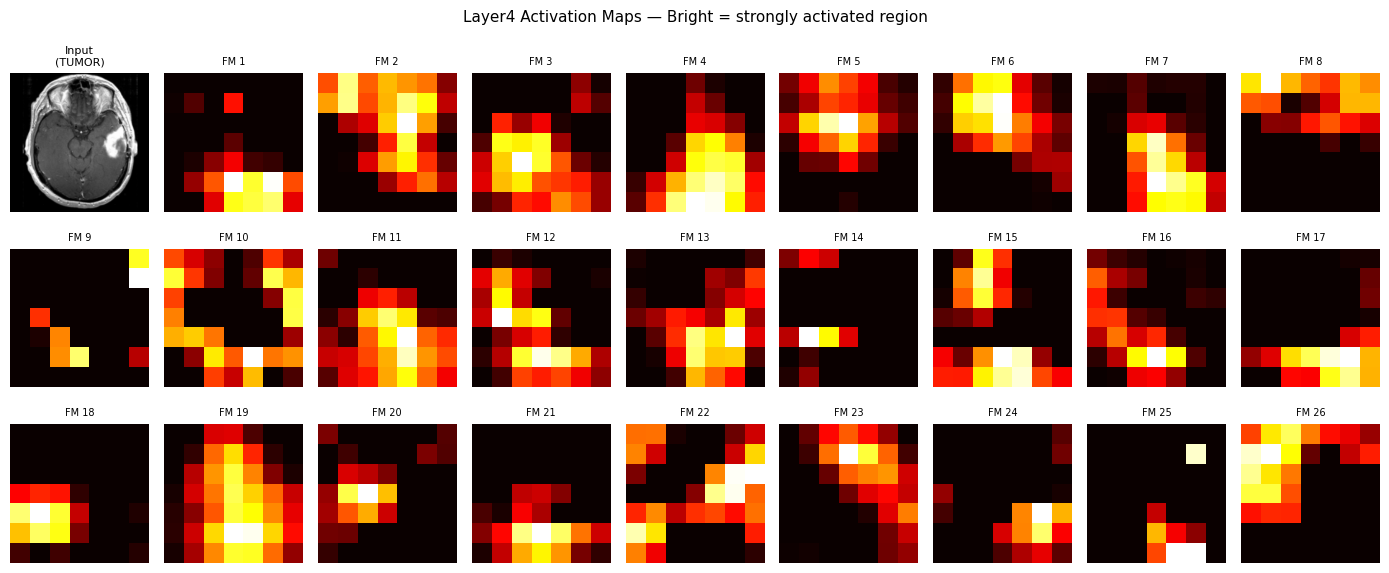

In [12]:
activation_store = {}

def hook_fn(module, inp, out):
    activation_store['layer4'] = out.detach()

hook = model.backbone.layer4.register_forward_hook(hook_fn)

sample_imgs, sample_lbls = next(iter(val_loader))
with torch.no_grad():
    _ = model(sample_imgs[:1].to(device))

hook.remove()

feat_maps = activation_store['layer4'].squeeze(0).cpu()  
print(f'Layer4 output shape: {feat_maps.shape}')

plt.figure(figsize=(14, 6))

plt.subplot(3, 9, 1)
plt.imshow(denorm(sample_imgs[0]))
lbl = CLASS_NAMES[sample_lbls[0].item()]
plt.title(f'Input\n({"TUMOR" if lbl=="yes" else "NORMAL"})', fontsize=8)
plt.axis('off')

for i in range(26):
    plt.subplot(3, 9, i+2)
    plt.imshow(feat_maps[i].numpy(), cmap='hot')
    plt.title(f'FM {i+1}', fontsize=7); plt.axis('off')

plt.suptitle('Layer4 Activation Maps — Bright = strongly activated region', fontsize=11)
plt.tight_layout(); plt.show()

In [13]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping."""

    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_backward_hook(self._bwd_hook)

    def _fwd_hook(self, m, inp, out):  self.activations = out.detach()
    def _bwd_hook(self, m, gi, go):    self.gradients   = go[0].detach()

    def generate(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)      

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True) 
        cam     = torch.relu((weights * self.activations).sum(dim=1)).squeeze()
        cam     = cam.cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  
        return cam, class_idx


def make_overlay(img_tensor, cam, alpha=0.45):
    """Blend Grad-CAM heatmap onto original image."""
    img   = denorm(img_tensor.squeeze(0))                         
    cam_r = cv2.resize(cam, (img.shape[1], img.shape[0]))         
    heat  = mpl_cm.jet(cam_r)[:, :, :3]                           
    blend = np.clip(alpha * heat + (1 - alpha) * img, 0, 1)
    return img, cam_r, blend


gradcam = GradCAM(model, target_layer=model.backbone.layer4[1].conv2)
print('Grad-CAM attached to layer4[1].conv2')

Grad-CAM attached to layer4[1].conv2


/Users/akhileshkumar/.pyenv/versions/3.10.5/lib/python3.10/site-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


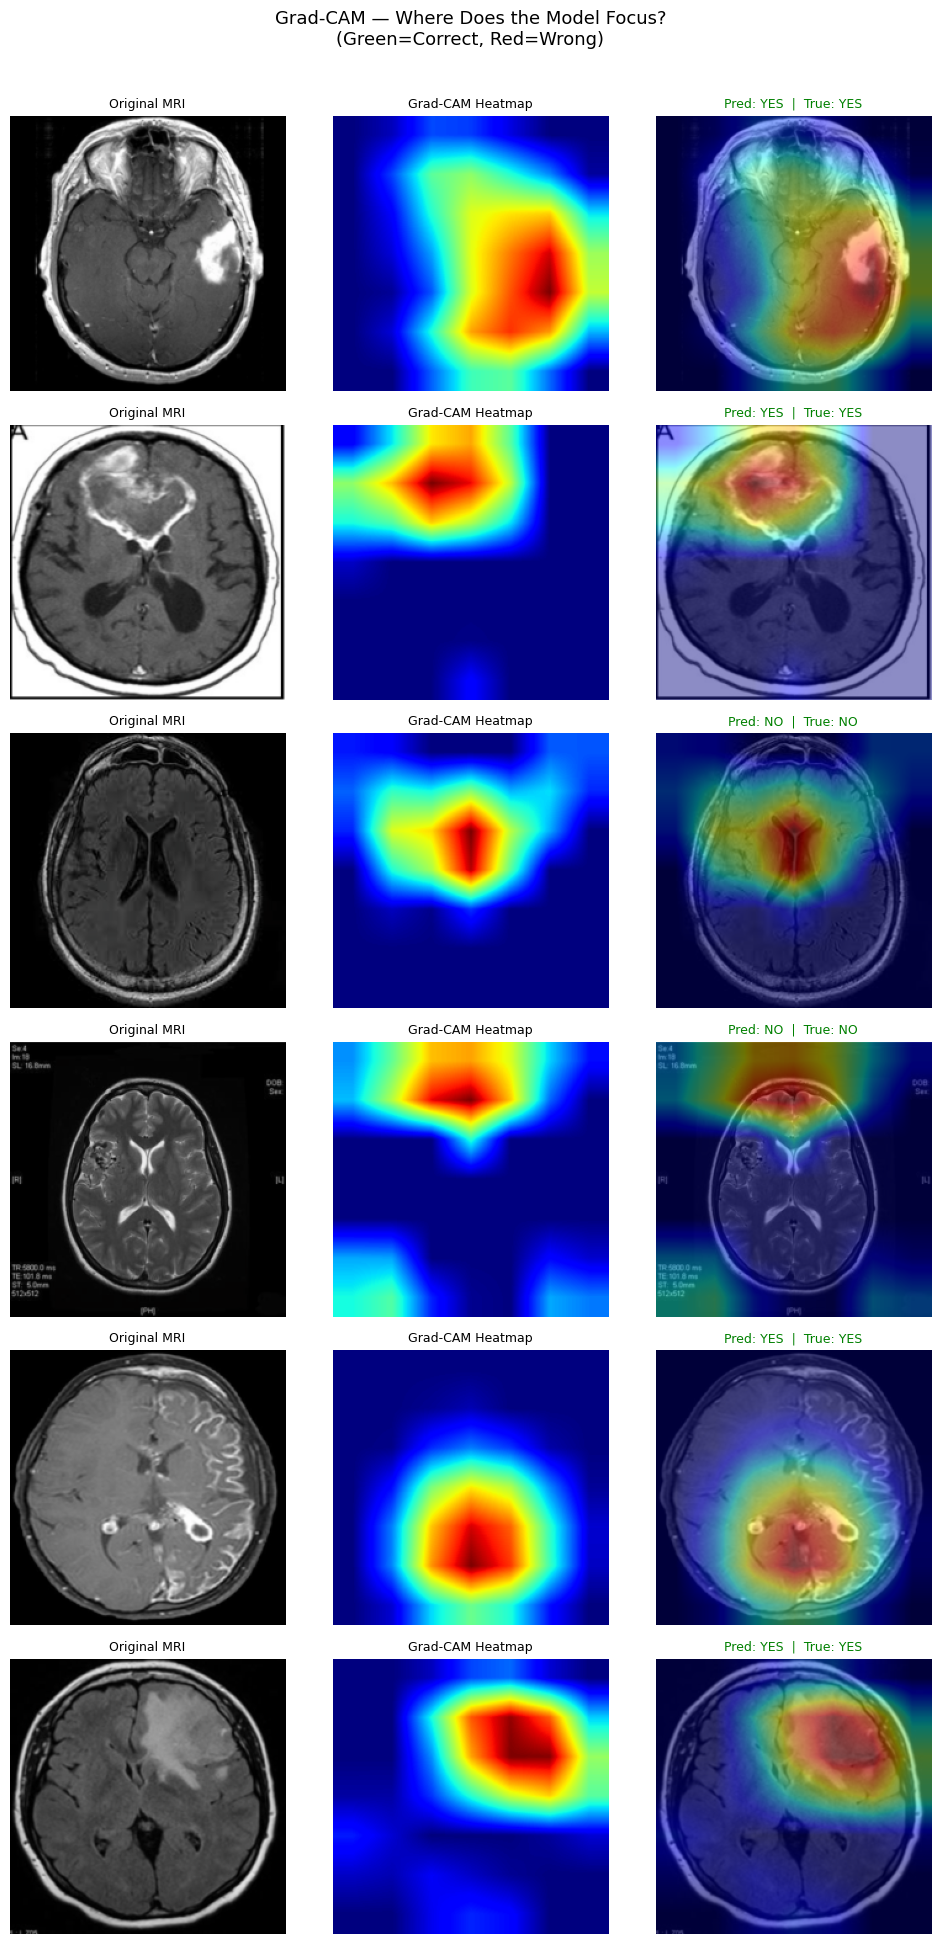

In [14]:
val_imgs, val_lbls = next(iter(val_loader))
n = min(6, len(val_imgs))

fig, axes = plt.subplots(n, 3, figsize=(10, n * 3.2))

for i in range(n):
    inp   = val_imgs[i:i+1].to(device)
    true  = CLASS_NAMES[val_lbls[i].item()]
    cam, pred_idx = gradcam.generate(inp)
    pred  = CLASS_NAMES[pred_idx]

    orig, heat, overlay = make_overlay(val_imgs[i:i+1], cam)
    ok    = pred == true
    color = 'green' if ok else 'red'

    axes[i,0].imshow(orig)
    axes[i,0].set_title('Original MRI', fontsize=9); axes[i,0].axis('off')

    axes[i,1].imshow(heat, cmap='jet')
    axes[i,1].set_title('Grad-CAM Heatmap', fontsize=9); axes[i,1].axis('off')

    axes[i,2].imshow(overlay)
    axes[i,2].set_title(f'Pred: {pred.upper()}  |  True: {true.upper()}',
                         fontsize=9, color=color)
    axes[i,2].axis('off')

plt.suptitle('Grad-CAM — Where Does the Model Focus?\n(Green=Correct, Red=Wrong)',
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

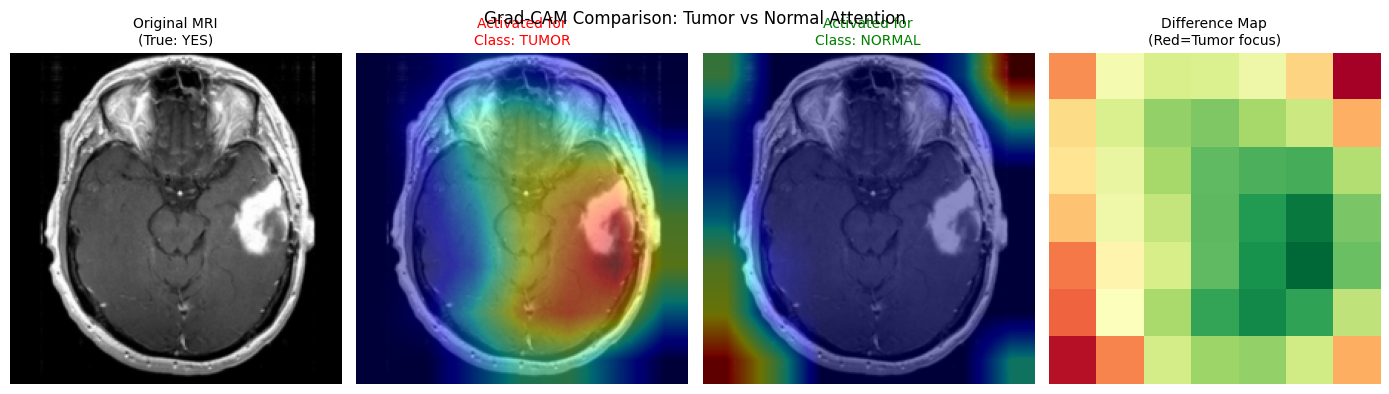

In [15]:
sample = val_imgs[0:1].to(device)
true   = CLASS_NAMES[val_lbls[0].item()]

cam_tumor,  _  = gradcam.generate(sample, class_idx=1) 
cam_normal, _  = gradcam.generate(sample, class_idx=0) 

orig,  _, ov_t  = make_overlay(val_imgs[0:1], cam_tumor)
_, _, ov_n      = make_overlay(val_imgs[0:1], cam_normal)

diff = cam_tumor - cam_normal  

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(orig)
axes[0].set_title(f'Original MRI\n(True: {true.upper()})', fontsize=10)

axes[1].imshow(ov_t)
axes[1].set_title('Activated for\nClass: TUMOR', fontsize=10, color='red')

axes[2].imshow(ov_n)
axes[2].set_title('Activated for\nClass: NORMAL', fontsize=10, color='green')

axes[3].imshow(diff, cmap='RdYlGn', vmin=-1, vmax=1)
axes[3].set_title('Difference Map\n(Red=Tumor focus)', fontsize=10)

for ax in axes: ax.axis('off')
plt.suptitle('Grad-CAM Comparison: Tumor vs Normal Attention', fontsize=12)
plt.tight_layout(); plt.show()

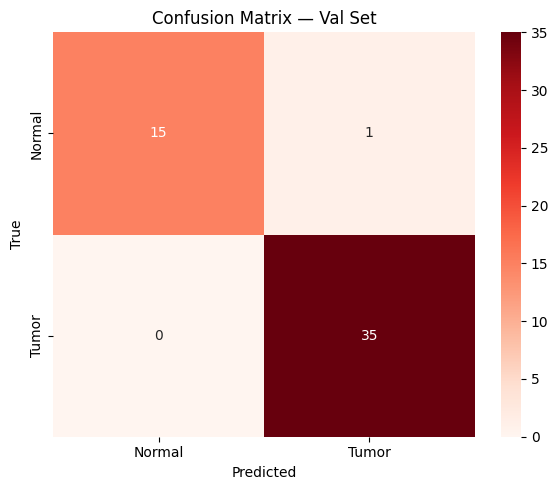

              precision    recall  f1-score   support

 Normal (no)       1.00      0.94      0.97        16
 Tumor (yes)       0.97      1.00      0.99        35

    accuracy                           0.98        51
   macro avg       0.99      0.97      0.98        51
weighted avg       0.98      0.98      0.98        51



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.load_state_dict(torch.load('best_brain_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        _, pred = model(imgs.to(device)).max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(lbls.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Normal','Tumor'],
            yticklabels=['Normal','Tumor'])
plt.title('Confusion Matrix — Val Set')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print(classification_report(all_labels, all_preds,
                             target_names=['Normal (no)', 'Tumor (yes)']))